# Part 1: Implementing a CSR matrix

## Defining personal class

In [135]:
from scipy.sparse.linalg import LinearOperator
import scipy.sparse as sp
import numpy as np


class CSRMatrix(LinearOperator):
    def __init__(self, coo_matrix: sp.coo_matrix) -> None:
        """Convert SciPy COO matrix into a custom CSR matrix object"""
        self.shape = coo_matrix.shape
        self.dtype = coo_matrix.dtype

        self.data = np.asarray(coo_matrix.data, dtype=self.dtype)
        self.rows = np.asarray(coo_matrix.row, dtype=np.int32)
        self.cols = np.asarray(coo_matrix.col, dtype=np.int32)

        self._convert_coo_to_csr(coo_matrix)

    def _convert_coo_to_csr(self, coo_matrix: sp.coo_matrix) -> "CSRMatrix":
        # Force C-style ordering
        sort_order = np.lexsort((self.cols, self.rows))

        self.data = self.data[sort_order]
        rows_sort = self.rows[sort_order]
        del self.rows # delete redundant data
        self.colidx = self.cols[sort_order]
        del self.cols

        # Initialise index pointer with zeros - 2 reasons for this;
        # 1. First value of indptr is always 0
        # 2. Easy to loop through and update after!
        self.indptr = np.zeros(self.shape[0]+1, dtype=np.int32)
        tally = np.bincount(rows_sort, minlength=self.shape[0])
        # minlength to zero-pad if last rows are empty, but bincount also
        # silently counts duplicates in COO format, if they exist some reason...
        # not ideal, but works properly if COO input formatted correctly

        # building indptr
        for i in range(self.shape[0]):
            self.indptr[i+1] = self.indptr[i] + tally[i]



    def __add__(self, other: "CSRMatrix") -> "CSRMatrix":
        """Add two CSR matrices."""
        assert self.shape == other.shape, "Incompatible matrix sizes. Arrays shape must be identical"
        # I wasn't sure if I was allowed to convert to COO and use the COO class
        # __add__ method, so I decided to go for a direct implementation...

        # This is annoying because:
        #   > CSR is hard to read in my head
        #   > We need to handle 2 cases;
        #       - matrix entries A_ij and B_ij both have a NNZ entry
        #       - only one of (or neither) entries A_ij, B_ij have a NNZ entry
        #     Both these cases require different handling... Let's proceed by
        #     copying duplicate entries into matrix A, and then simply appending
        #     the remaining entries.

        A_data, B_data      = self.data, other.data
        A_cols, B_cols      = self.colidx, other.colidx
        A_indptr, B_indptr  = self.indptr, other.indptr

        sum_data    = []
        sum_colidx  = []
        sum_indptr  = [0]

        n_rows = self.shape[0]

        for i in range(n_rows):
            # Initialise counters
            A_start, A_end = A_indptr[i], A_indptr[i+1]
            B_start, B_end = B_indptr[i], B_indptr[i+1]

            a_ptr, b_ptr = A_start, B_start

            # Merging data for...
            while a_ptr < A_end and b_ptr < B_end:
                a_colidx = A_cols[a_ptr]
                b_colidx = B_cols[b_ptr]

                a_data = A_data[a_ptr]
                b_data = B_data[b_ptr]
                # All shared NNZ entries;
                if a_colidx == b_colidx:
                    val = a_data + b_data
                    if val != 0:
                        sum_data.append(val)
                        sum_colidx.append(a_colidx)

                    a_ptr += 1
                    b_ptr += 1
                # All entries where only A has data
                elif a_colidx < b_colidx:
                    sum_data.append(a_data)
                    sum_colidx.append(a_colidx)
                    a_ptr += 1

                # All entries where only B has data
                else:
                    sum_data.append(b_data)
                    sum_colidx.append(b_colidx)
                    b_ptr += 1

              # If we run out of B NNZ entries...
            while a_ptr < A_end:
                sum_data.append(A_data[a_ptr])
                sum_colidx.append(A_cols[a_ptr])
                a_ptr += 1

              # If we run out of A NNZ entries...
            while b_ptr < B_end:
                sum_data.append(B_data[b_ptr])
                sum_colidx.append(B_cols[b_ptr])
                b_ptr += 1

            sum_indptr.append(len(sum_data))

        sum_data   = np.array(sum_data, dtype=self.dtype)
        sum_colidx = np.array(sum_colidx, dtype=np.int32)
        sum_indptr = np.array(sum_indptr, dtype=np.int32)

        # Since we only defined our __init__ method to deal with COO inputs,
        # we need to create a new un-initialised object, and we will pass the
        # necessary agruments manually.
        ans = CSRMatrix.__new__(CSRMatrix)
        ans.shape  = self.shape
        ans.dtype  = self.dtype
        ans.data   = sum_data
        ans.colidx = sum_colidx
        ans.indptr = sum_indptr
        return ans

    def _matvec(self, other: np.ndarray):
        """Compute a matrix-vector product."""
        assert self.shape[1] == len(other), "Incompatible matrix/vector sizes"

        ans = np.empty(self.shape[0], dtype=self.dtype)

        for i in range(self.shape[0]):
            start = self.indptr[i]
            end   = self.indptr[i+1]

            mat_row_data = self.data[start:end]
            vec_data = other[self.colidx[start:end]]

            ans[i] = np.dot(mat_row_data, vec_data)

        return ans

    def toarray(self) -> np.ndarray:
        M = np.zeros(self.shape, dtype=self.dtype)
        for i in range(self.shape[0]):
            start = self.indptr[i]
            end   = self.indptr[i+1]
            cols  = self.colidx[start:end]
            vals  = self.data[start:end]
            M[i,cols] = vals
        return M

In [136]:
0.0 != 0, 0 != 0.0 #returns (False, False) - works even if 0 entries are float!

(False, False)

## Testing/benchmarking new class:

In [137]:
import random

n=10
alpha = np.round(random.uniform(0., 1.), 6)

rand_vec = np.random.rand(n)
id_mat = np.eye(n)
zero_mat = 0*id_mat
CD_mat = (1-2*alpha)*id_mat + np.diag([alpha for _ in range(n-1)], k=1) + np.diag([alpha for _ in range(n-1)], k=-1)
neumann_CD_mat = CD_mat
if True:
  neumann_CD_mat[-1][-1] = 3
  neumann_CD_mat[-1][-2] = -4
  neumann_CD_mat[-1][-3] = 1
cross_mat = id_mat + np.fliplr(id_mat)
ones_mat = zero_mat.copy()
ones_mat.fill(1) #100% dense matrix, just for fun

In [138]:
mats = [id_mat, alpha*id_mat, CD_mat, neumann_CD_mat, cross_mat, ones_mat, alpha*ones_mat]
coo_mats = [sp.coo_matrix(mat) for mat in mats]
csr_mats = [CSRMatrix(mat) for mat in coo_mats]

In [139]:
for i in range(len(mats)):
  for j in range(len(mats)):
    #print(f"Addition Index:({i}, {j})")
    assert np.allclose((csr_mats[i]+csr_mats[j]).toarray(), (coo_mats[i]+coo_mats[j]).toarray())
  #print(f"Multiplication Index:({i})")
  assert np.allclose((csr_mats[i] @ rand_vec),(coo_mats[i] @ rand_vec))

Code runs without any assertion errors, so our method works just fine with the above example matrices.

Time to benchmark now.

In [165]:
ns = [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10_000]
times_numpy = []
times_custom = []


for n in ns:
    rand_vec = np.random.rand(n)

    id_mat = np.eye(n)
    CD_mat = (1-2*alpha)*id_mat + np.diag([alpha for _ in range(n-1)], k=1) + np.diag([alpha for _ in range(n-1)], k=-1)
    neumann_CD_mat = CD_mat
    if True:
        neumann_CD_mat[-1][-1] = 3
        neumann_CD_mat[-1][-2] = -4
        neumann_CD_mat[-1][-3] = 1

    test_mat = neumann_CD_mat + np.fliplr(id_mat)
    COO_test_mat = sp.coo_matrix(test_mat)
    CSR_test_mat = CSRMatrix(COO_test_mat)

    t = %timeit -o -q -n10 -r3 test_mat @ rand_vec
    times_numpy.append(t.average)
    t = %timeit -o -q -n10 -r3 CSR_test_mat @ rand_vec
    times_custom.append(t.average)

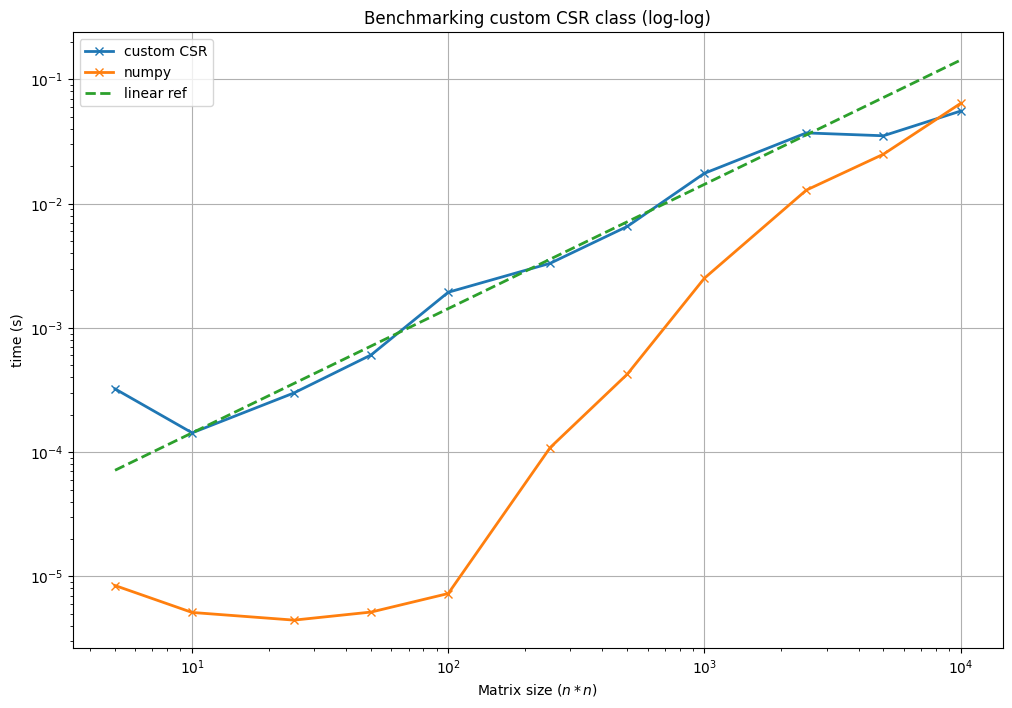

In [166]:
import matplotlib.pyplot as plt

scalar = times_custom[1] / ns[1]
linear_ref = [scalar * n for n in ns]

plt.figure(figsize=(12,8))
plt.loglog(ns, times_custom, "-x", label="custom CSR", lw=2.)
plt.loglog(ns, times_numpy, "-x", label="numpy", lw=2.)
plt.loglog(ns, linear_ref, "--", label="linear ref", lw=2.)
plt.grid()
plt.legend()
plt.title("Benchmarking custom CSR class (log-log)")
plt.xlabel("Matrix size $(n*n)$")
plt.ylabel("time (s)")
plt.show()

As seen above, our custom class has a bit more overhead, but after that seems to grow linearly, as opposed to the dense method, which grows quicker. Thus our method is better for larger matrices (order $10^4$ and higher)

One may spend some time to lower the overhead, but this is good enough as a proof of concept, and I am no C-wizard, so this will have to suffice.

## Using gmres, cg on custom class

gmres can handle any square matrix, but cg can only handle SPD matrices, so let us build such a matrix...

In [142]:
n = 50

rand_vec = np.random.rand(n)

alpha = np.round(np.random.rand(), 6)
test_mat = (1+2*alpha)*np.eye(n)
test_mat += np.diag([-alpha for _ in range(n-1)], k=1)
test_mat += np.diag([-alpha for _ in range(n-1)], k=-1)

COO_test_mat = sp.coo_matrix(test_mat)
CSR_test_mat = CSRMatrix(COO_test_mat)

In [143]:
from scipy.sparse.linalg import gmres, cg

x_gmres = gmres(CSR_test_mat, rand_vec)
x_cg = cg(CSR_test_mat, rand_vec)

#print(x_gmres)
#print("---")
#print(x_cg)

print(f"""Both answers agree to 5 d.p.: {np.allclose(x_gmres[0], x_cg[0],
                                                      atol=1e-5, rtol=0)}""")
print(f"""Both answers agree to 6 d.p.: {np.allclose(x_gmres[0], x_cg[0],
                                                      atol=1e-6, rtol=0)}""")

Both answers agree to 5 d.p.: True
Both answers agree to 6 d.p.: False


As we see, our answers agree to 5 decimal places, but not to 6. There are a couple of reasons for this, but they both boil down to machine rounding error.

 - The two methods normalise in different ways (GMRes normalises using the 2-norm, while CG normalises with the matrix-norm);
 - Floating point round-off error (which is why the above point matters, too) causes the Krylov subspaces of both methods to slightly differ.

# Part 2: Implementing a custom matrix

## Building custom matrix

We build a custom class to contain the matrix A, as specified in the assignment brief.

We do this, because it has special structure in the 4th (bottom right) quadrant, that we can abuse in order to squeeze out better performance than a standard numpy (dense quadrant 4) method/representation.

In [167]:
class TWMatrix(LinearOperator):
    def __init__(self, diag: np.ndarray, Tall_mat, Wide_mat) -> None:
        """Save matrix A with special structure:

            [ diag(D)   0 ]
            [   0     T@W ]

            where T is a (n,2) matrix and W is a (n,2) matrix
        """

        assert diag.ndim == 1, "Diag arg expects 1-dim array"

        self.diag  = diag
        self.n     = len(self.diag)
        self.shape = (2*self.n, 2*self.n)
        self.dtype = Tall_mat.dtype
        self.Tall  = Tall_mat
        self.Wide  = Wide_mat

        assert Tall_mat.shape == (self.n, 2), f"Tall_mat must be ({self.n}, 2)"
        assert Wide_mat.shape == (2, self.n), f"Wide_mat must be (2, {self.n})"


    def _matvec(self, other: np.ndarray):
        assert other.shape[0] == 2*self.n
        Q1 = self.diag * other[:self.n] #elementwise mult
        Q4 = self.Tall @ (self.Wide @ other[self.n:]) #np.dot()
        return np.concatenate([Q1, Q4])

    def toarray(self): # for checking
        n = self.n
        A = np.zeros((2*n, 2*n), dtype=self.dtype)
        A[:n, :n] = np.diag(self.diag)
        A[n:, n:] = self.Tall @ self.Wide

        return A

As assignment specified, no \_\_add\_\_ method was defined, however I did define a toarray() method in order to be able to compare and verify that I was indeed getting a correct matrix. See below.

In [168]:
ns = [5, 10, 25, 50, 100, 250]

for n in ns:
    D = np.random.rand(n)
    T = np.random.rand(n, 2)
    W = np.random.rand(2, n)
    Z = np.zeros((n,n))

    A = np.block([[np.diag(D), Z], [Z, T@W]])

    print(np.allclose(A, TWMatrix(D, T, W).toarray(), rtol=0, atol=1e-100000))

True
True
True
True
True
True


Indeed we can see that our matrices match to machine accuracy (I was too lazy to figure out what the exact exponent I need is, so I just tried a clearly overvalued one and code ran fine, so I assume atol is accordingly rounded silently).

## Testing new matrix

In [169]:
ns = [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
times_COO = []
times_custom = []

for n in ns:
    v = np.random.rand(2*n) # assuming we are asked for a random v, too
    D = np.random.rand(n)
    T = np.random.rand(n, 2)
    W = np.random.rand(2, n)

    A_TW = TWMatrix(D, T, W)
    A = np.asarray(A_TW.toarray())
    A_COO = sp.coo_matrix(A)

    t = %timeit -o -q -n30 -r4 A_TW @ v
    times_custom.append(t.average)

    t = %timeit -o -q -n30 -r4 A_COO @ v
    times_COO.append(t.average)

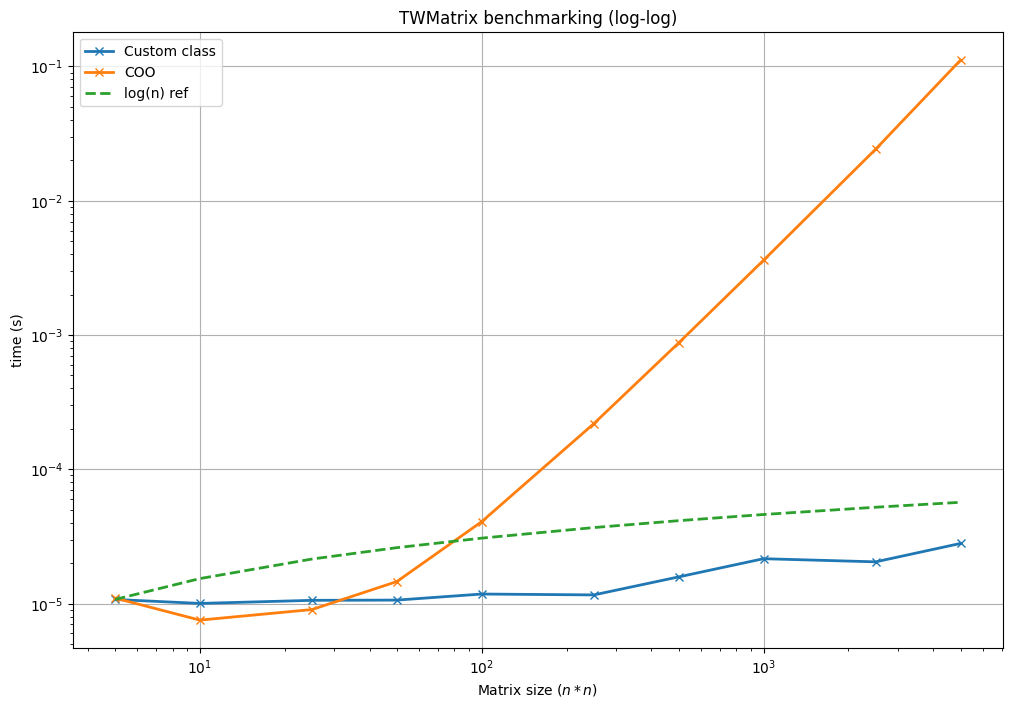

In [170]:
scalar = times_custom[0] / np.log(ns[0])
log_ref = [scalar * np.log(n) for n in ns]

plt.figure(figsize=(12,8))
plt.loglog(ns, times_custom, "-x", label="Custom class", lw=2.)
plt.loglog(ns, times_COO, "-x", label="COO", lw=2.)
plt.loglog(ns, log_ref, "--", label="log(n) ref", lw=2.)
plt.grid()
plt.legend()
plt.title("TWMatrix benchmarking (log-log)")
plt.xlabel("Matrix size ($n*n$)")
plt.ylabel("time (s)")
plt.show()

NOTE: log(n) reference line is NOT ASYMPTOTICALLY RELEVANT!!! We are looking at time complexity $O(NNZ)$, but the log graph was just a good fit in order to understand was was going on, roughly. Overhead dominates the graph at these small $N$-values, we possibly see some of the $O(NNZ)$ behaviour appear after $N\geq500$.

---

We see that our method has some additional overhead, but it remains way faster than the standard implementation, which does not abuse the special structure we have for this problem.

The entire point of creating our custom class TWMatrix() is because we can represent the 4th quadrant of the matrix A, from the brief, as the matrix product of a $(n,2)$ and a $(n,2)$ matrix. We are thus abusing this structure so that we do not need to compute and store the product $TW$ (which is an $(n,n)$ matrix), but can get away with storing both $T, W$ and then when we compute the _matvec product $TWv$, we first do $Wv$, which is $O(2n)$, and then $T(Wv)$, which is another $O(2n)$ - total $O(4n)$.

Without abusing this special structure, we are forced to compute $TW$, which is $O(n^2)$ naively.

# Conclusion

## Part 1:

I'm quite happy with my implementation. I would have liked to have a clean docstring and more precise input data types specified, but it got too much when I realised that my \_\_add\_\_ and \_matvec methods need to be able to accept multiple types of matrices, and I'm running out of time for the assignment to be spending time on docstrings.

I also specified in the code, but my implementation uses .npbincount(), which silently counts any duplicate entries that might exist in the COO matrix input in \_\_init\_\_. This means that if the COO matrix has 2+ instances stored for a single entry, my implementation will count both, which will mess with the output. Ideally, I would raise an error if there are any duplicates in the COO input, but... I will rely on the user to have correctly formatted COO matrices instead.

## Part 2:

As in part 1, I wish I had cleaner docstrings and clearly defined input/output types, but I am running out of time, and it seems too much effort for an assignment that does not require it...

I would also have liked to create a method that can count the NNZ entries in my TWMatrix class so that I could create a clean graph with a pretty reference line... I know I can estimate it by $O(n)$, but that's heavy-handed, AND;

I do not have enough $N-$values to have an adequate graph, but the computation time is too long to wait for any further (larger) entries.

(I also could have benchmarked against other storage conventions, but this is sufficient to illustrate my point.)

## Overall

My implementations have met the functional and peformance requirements of the assignment, as can be seen from the benchmarking and (although not extensive;) testing with sample arrays - indeed we successfully implemented a custom CSR class which correctly evaluates matrix addition and matvec operations, and we exploit the special structure of the assignment matrix (A) and successfully beat SciPy's methods which do NOT exploit said structure (and are thus slow).